# Supervised Learning — From Basics to Advanced

A complete, self-contained walkthrough of supervised machine learning: the math, the intuition, the code, and the plots.

**Structure of every section:**
1. Concept & intuition
2. Math
3. Implementation (from scratch, then scikit-learn)
4. Visualization
5. Evaluation

---

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve, auc,
                              precision_recall_curve, ConfusionMatrixDisplay)

np.random.seed(42)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2"]
print("Environment ready.")

Environment ready.


## 1. What Is Supervised Learning?

We have a dataset of $n$ examples $\{(x^{(i)}, y^{(i)})\}_{i=1}^n$ where $x^{(i)} \in \mathbb{R}^d$ is a feature vector and $y^{(i)}$ is a known label.

- **Regression**: $y \in \mathbb{R}$ (continuous) — e.g. predicting a price.
- **Classification**: $y \in \{1, \dots, K\}$ (discrete) — e.g. predicting spam vs. not spam.

The goal is to learn a function $f_\theta(x)$, parameterized by $\theta$, that generalizes well to **unseen** data — not just memorizes the training set. We do this by defining a **loss function** $L(\theta)$ that measures how wrong our predictions are, and minimizing it (usually via gradient descent).

$$\theta^* = \arg\min_\theta \; \frac{1}{n}\sum_{i=1}^n \ell\big(f_\theta(x^{(i)}), y^{(i)}\big) + \lambda R(\theta)$$

where $\ell$ is a per-example loss and $R(\theta)$ is an optional regularization term that penalizes complexity.

## 2. Linear Regression

### 2.1 Model
$$\hat{y} = f_\theta(x) = \theta_0 + \theta_1 x_1 + \dots + \theta_d x_d = \theta^\top x$$

### 2.2 Loss — Mean Squared Error (MSE)
$$J(\theta) = \frac{1}{2n}\sum_{i=1}^n \left(\theta^\top x^{(i)} - y^{(i)}\right)^2$$

### 2.3 Closed-form solution (Normal Equation)
$$\theta = (X^\top X)^{-1} X^\top y$$

### 2.4 Gradient Descent (used when $X^\top X$ is too large to invert)
$$\nabla_\theta J = \frac{1}{n} X^\top (X\theta - y), \qquad \theta \leftarrow \theta - \alpha \nabla_\theta J$$

$\alpha$ is the **learning rate**. Too large → divergence; too small → slow convergence.

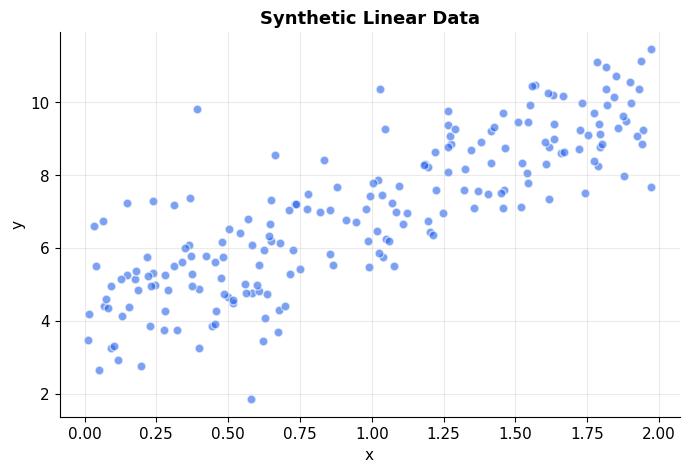

In [2]:
# Synthetic dataset: y = 4 + 3x + noise
X_lin = 2 * np.random.rand(200, 1)
y_lin = 4 + 3 * X_lin.squeeze() + np.random.randn(200) * 1.2

plt.scatter(X_lin, y_lin, alpha=0.6, color=COLORS[0], edgecolor="white", s=40)
plt.title("Synthetic Linear Data")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

Learned theta (from scratch): intercept=4.093, slope=2.982


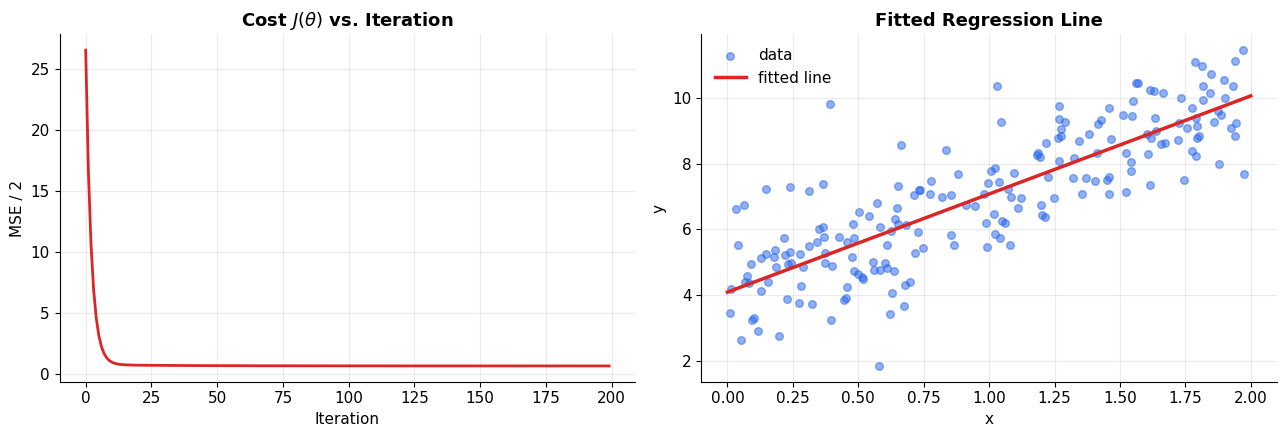

In [3]:
# --- From scratch: Batch Gradient Descent ---
X_b = np.c_[np.ones((len(X_lin), 1)), X_lin]  # add bias column
theta = np.zeros(2)
lr = 0.1
n_iters = 200
history = []

for it in range(n_iters):
    preds = X_b @ theta
    error = preds - y_lin
    grad = (1/len(y_lin)) * X_b.T @ error
    theta -= lr * grad
    history.append(0.5 * np.mean(error**2))

print(f"Learned theta (from scratch): intercept={theta[0]:.3f}, slope={theta[1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(history, color=COLORS[1], lw=2)
axes[0].set_title("Cost $J(\\theta)$ vs. Iteration")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("MSE / 2")

axes[1].scatter(X_lin, y_lin, alpha=0.5, color=COLORS[0], s=30, label="data")
x_line = np.linspace(0, 2, 100)
axes[1].plot(x_line, theta[0] + theta[1]*x_line, color=COLORS[1], lw=2.5, label="fitted line")
axes[1].set_title("Fitted Regression Line")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y"); axes[1].legend()
plt.tight_layout(); plt.show()

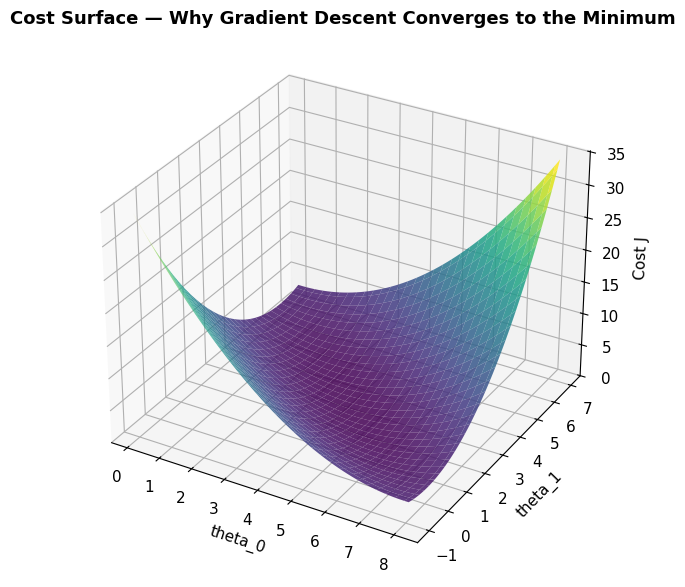

In [4]:
# --- 3D cost surface: visualize why gradient descent works ---
from mpl_toolkits.mplot3d import Axes3D  # noqa

t0_range = np.linspace(theta[0]-4, theta[0]+4, 60)
t1_range = np.linspace(theta[1]-4, theta[1]+4, 60)
T0, T1 = np.meshgrid(t0_range, t1_range)
J_vals = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        preds = X_b @ np.array([T0[i,j], T1[i,j]])
        J_vals[i,j] = 0.5*np.mean((preds - y_lin)**2)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.85, linewidth=0)
ax.set_xlabel('theta_0'); ax.set_ylabel('theta_1'); ax.set_zlabel('Cost J')
ax.set_title('Cost Surface — Why Gradient Descent Converges to the Minimum')
plt.tight_layout(); plt.show()

In [5]:
# --- sklearn version + evaluation ---
from sklearn.linear_model import LinearRegression

Xtr, Xte, ytr, yte = train_test_split(X_lin, y_lin, test_size=0.2, random_state=42)
lin_reg = LinearRegression().fit(Xtr, ytr)
pred = lin_reg.predict(Xte)

print(f"sklearn intercept={lin_reg.intercept_:.3f}, slope={lin_reg.coef_[0]:.3f}")
print(f"MSE={mean_squared_error(yte, pred):.3f}   R2={r2_score(yte, pred):.3f}")

sklearn intercept=4.017, slope=3.063
MSE=1.562   R2=0.572


### 2.5 Polynomial Regression & the Bias–Variance Tradeoff

Linear regression can fit non-linear data by adding polynomial features: $x \to (x, x^2, x^3, \dots)$.

- **High bias (underfitting)**: model too simple, misses the pattern.
- **High variance (overfitting)**: model too complex, fits noise instead of signal.

$$\text{Expected Test Error} = \underbrace{\text{Bias}^2}_{\text{too simple}} + \underbrace{\text{Variance}}_{\text{too sensitive}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

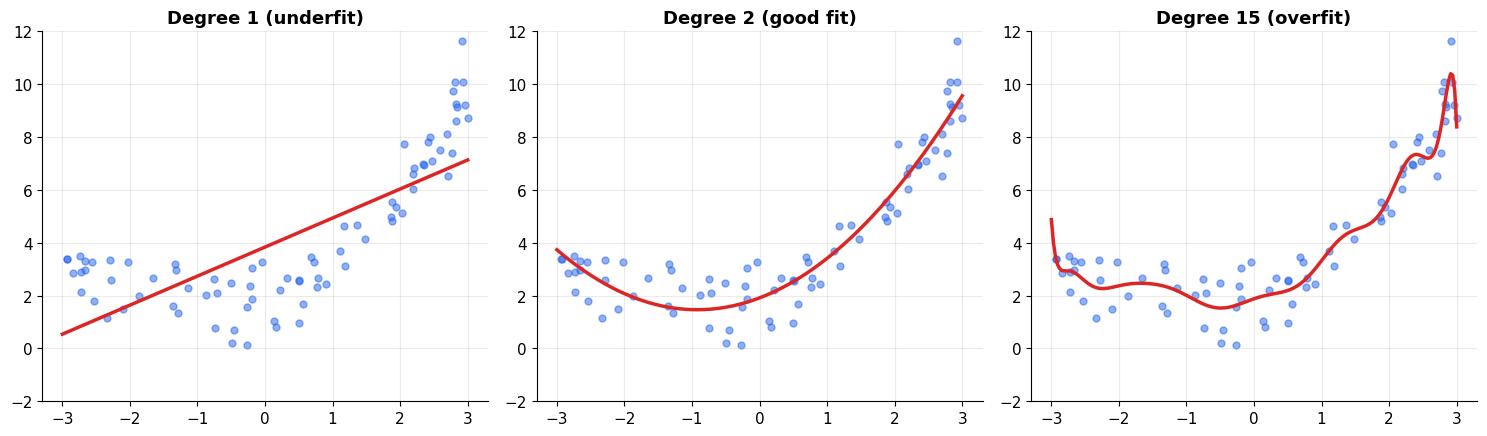

In [6]:
X_poly = np.sort(np.random.rand(80, 1) * 6 - 3, axis=0)
y_poly = 0.5*X_poly.squeeze()**2 + X_poly.squeeze() + 2 + np.random.randn(80)*0.8

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, degree, label in zip(axes, [1, 2, 15], ["Degree 1 (underfit)", "Degree 2 (good fit)", "Degree 15 (overfit)"]):
    poly = PolynomialFeatures(degree=degree)
    Xp = poly.fit_transform(X_poly)
    model = LinearRegression().fit(Xp, y_poly)
    x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
    y_plot = model.predict(poly.transform(x_plot))
    ax.scatter(X_poly, y_poly, alpha=0.5, color=COLORS[0], s=25)
    ax.plot(x_plot, y_plot, color=COLORS[1], lw=2.5)
    ax.set_title(label); ax.set_ylim(-2, 12)
plt.tight_layout(); plt.show()

## 3. Regularization — Ridge & Lasso

To fight overfitting we penalize large weights.

- **Ridge (L2)**: $J(\theta) = \text{MSE} + \lambda \sum_j \theta_j^2$ — shrinks weights smoothly, never exactly zero.
- **Lasso (L1)**: $J(\theta) = \text{MSE} + \lambda \sum_j |\theta_j|$ — can zero out weights entirely (feature selection).

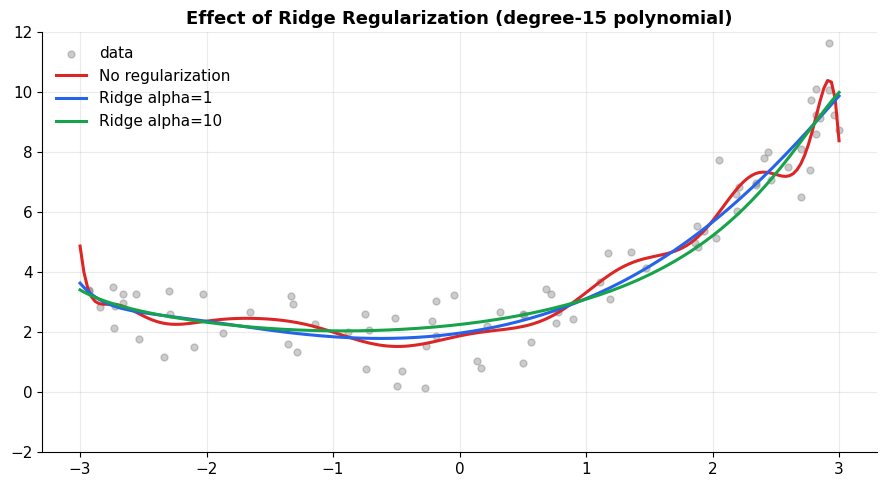

In [7]:
from sklearn.linear_model import Ridge, Lasso

poly15 = PolynomialFeatures(degree=15)
Xp15 = poly15.fit_transform(X_poly)
scaler = StandardScaler().fit(Xp15)
Xp15_scaled = scaler.transform(Xp15)

fig, ax = plt.subplots(figsize=(9,5))
x_plot = np.linspace(-3, 3, 200).reshape(-1,1)
x_plot_p = scaler.transform(poly15.transform(x_plot))
ax.scatter(X_poly, y_poly, alpha=0.4, color="gray", s=25, label="data")

for alpha, color, name in [(0, COLORS[1], "No regularization"),
                             (1, COLORS[0], "Ridge alpha=1"),
                             (10, COLORS[2], "Ridge alpha=10")]:
    model = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
    model.fit(Xp15_scaled, y_poly)
    ax.plot(x_plot, model.predict(x_plot_p), color=color, lw=2.2, label=name)
ax.set_ylim(-2, 12); ax.set_title("Effect of Ridge Regularization (degree-15 polynomial)")
ax.legend(); plt.tight_layout(); plt.show()

Lasso zeroed out 13 / 16 polynomial-feature coefficients.


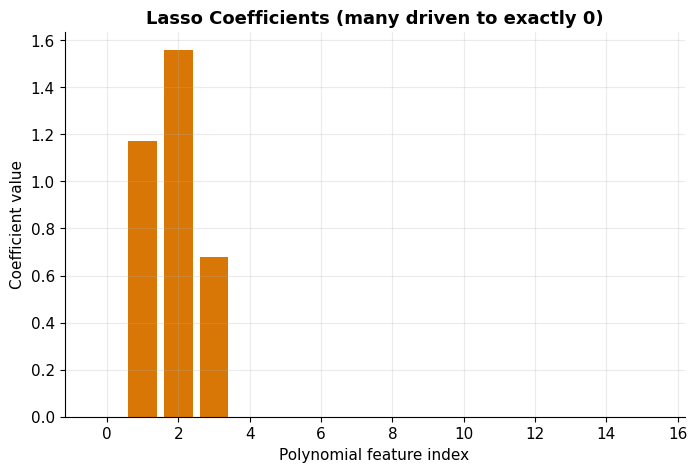

In [8]:
# Lasso driving coefficients exactly to zero -> feature selection
lasso = Lasso(alpha=0.05, max_iter=10000).fit(Xp15_scaled, y_poly)
n_zero = np.sum(np.abs(lasso.coef_) < 1e-6)
print(f"Lasso zeroed out {n_zero} / {len(lasso.coef_)} polynomial-feature coefficients.")

plt.bar(range(len(lasso.coef_)), lasso.coef_, color=COLORS[3])
plt.title("Lasso Coefficients (many driven to exactly 0)")
plt.xlabel("Polynomial feature index"); plt.ylabel("Coefficient value")
plt.show()

## 4. Logistic Regression (Classification)

### 4.1 Model — the Sigmoid
$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \hat{p} = \sigma(\theta^\top x) = P(y=1 \mid x)$$

Sigmoid squashes any real number into $(0,1)$, so it can be read as a probability.

### 4.2 Loss — Binary Cross-Entropy
$$J(\theta) = -\frac{1}{n}\sum_{i=1}^n \Big[y^{(i)}\log \hat p^{(i)} + (1-y^{(i)})\log(1-\hat p^{(i)})\Big]$$

This penalizes confident-and-wrong predictions heavily (log goes to $-\infty$ near 0).

### 4.3 Gradient (identical form to linear regression!)
$$\nabla_\theta J = \frac{1}{n} X^\top(\hat{p} - y)$$

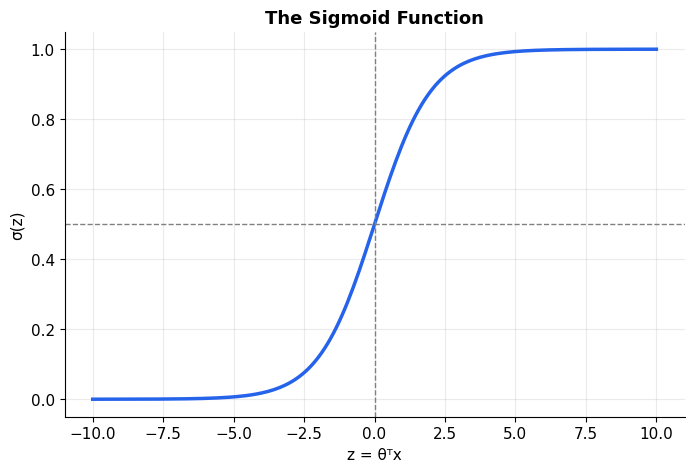

In [9]:
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))
plt.plot(z, sigmoid, color=COLORS[0], lw=2.5)
plt.axhline(0.5, color='gray', ls='--', lw=1)
plt.axvline(0, color='gray', ls='--', lw=1)
plt.title("The Sigmoid Function")
plt.xlabel("z = θᵀx"); plt.ylabel("σ(z)")
plt.show()

Accuracy: 0.987


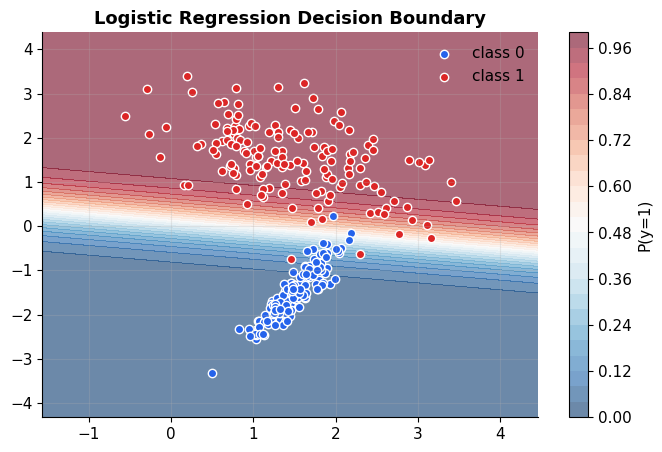

In [10]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

Xc, yc = make_classification(n_samples=300, n_features=2, n_redundant=0,
                              n_clusters_per_class=1, class_sep=1.5, random_state=42)
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25, random_state=42)

log_reg = LogisticRegression().fit(Xtr, ytr)
pred = log_reg.predict(Xte)
print(f"Accuracy: {accuracy_score(yte, pred):.3f}")

# Decision boundary plot
xx, yy = np.meshgrid(np.linspace(Xc[:,0].min()-1, Xc[:,0].max()+1, 300),
                      np.linspace(Xc[:,1].min()-1, Xc[:,1].max()+1, 300))
Z = log_reg.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=25, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label="P(y=1)")
plt.scatter(Xc[yc==0,0], Xc[yc==0,1], color=COLORS[0], edgecolor='white', label='class 0')
plt.scatter(Xc[yc==1,0], Xc[yc==1,1], color=COLORS[1], edgecolor='white', label='class 1')
plt.title("Logistic Regression Decision Boundary")
plt.legend(); plt.show()

## 5. Classification Evaluation Metrics

From the confusion matrix (TP, FP, TN, FN):

$$\text{Precision} = \frac{TP}{TP+FP} \qquad \text{Recall} = \frac{TP}{TP+FN} \qquad F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

**ROC curve**: True Positive Rate vs. False Positive Rate at every threshold. **AUC** = probability the model ranks a random positive above a random negative.

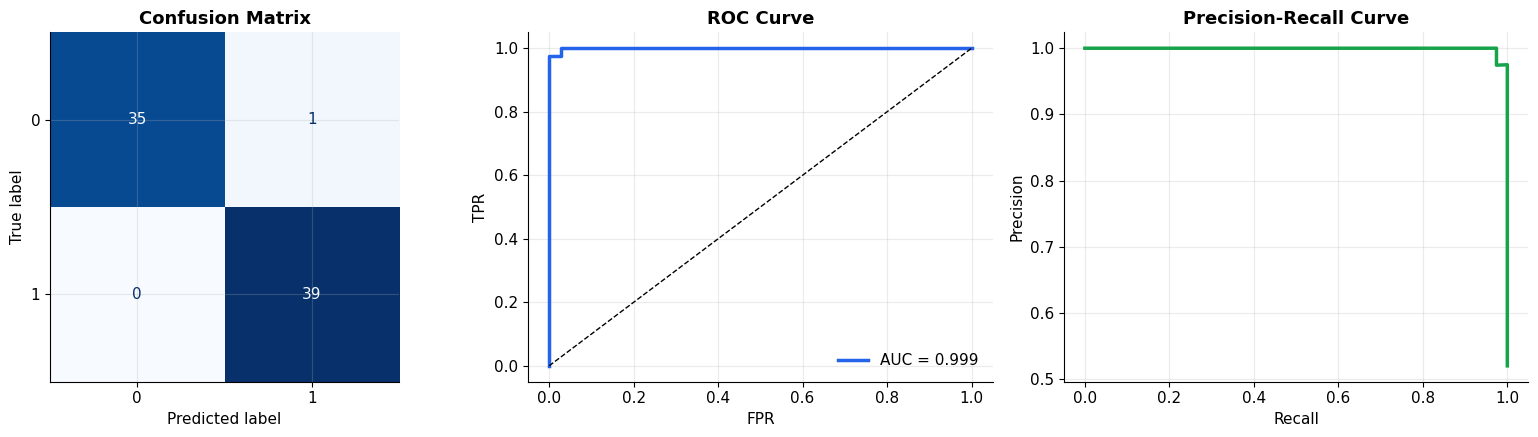

Precision=0.975  Recall=1.000  F1=0.987


In [11]:
probs = log_reg.predict_proba(Xte)[:,1]
fpr, tpr, _ = roc_curve(yte, probs)
roc_auc = auc(fpr, tpr)
prec, rec, _ = precision_recall_curve(yte, probs)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay(confusion_matrix(yte, pred)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Confusion Matrix")

axes[1].plot(fpr, tpr, color=COLORS[0], lw=2.5, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_title("ROC Curve"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

axes[2].plot(rec, prec, color=COLORS[2], lw=2.5)
axes[2].set_title("Precision-Recall Curve"); axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")

plt.tight_layout(); plt.show()
print(f"Precision={precision_score(yte,pred):.3f}  Recall={recall_score(yte,pred):.3f}  F1={f1_score(yte,pred):.3f}")

## 6. K-Nearest Neighbors (KNN)

**No training phase** — KNN is "lazy": it memorizes the data. To predict a new point, find its $k$ nearest neighbors (by e.g. Euclidean distance $d(x,x')=\|x-x'\|_2$) and take a majority vote (classification) or average (regression).

- Small $k$ → low bias, high variance (jagged, overfit boundary).
- Large $k$ → high bias, low variance (smooth, underfit boundary).

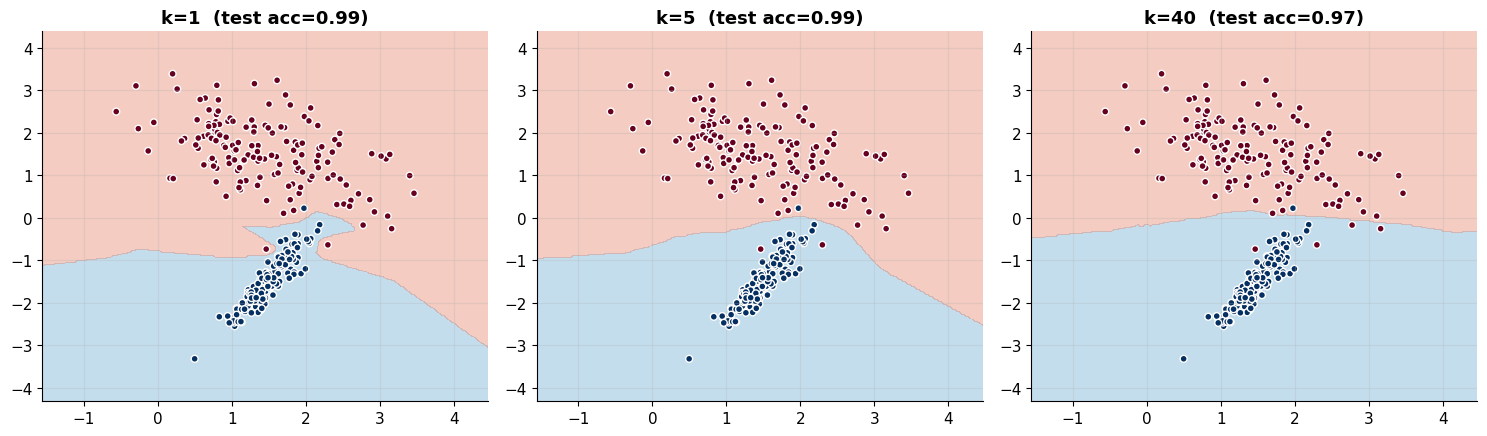

In [12]:
from sklearn.neighbors import KNeighborsClassifier

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, k in zip(axes, [1, 5, 40]):
    knn = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr)
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, cmap='RdBu_r', alpha=0.4)
    ax.scatter(Xc[:,0], Xc[:,1], c=yc, cmap='RdBu_r', edgecolor='white', s=25)
    acc = accuracy_score(yte, knn.predict(Xte))
    ax.set_title(f"k={k}  (test acc={acc:.2f})")
plt.tight_layout(); plt.show()

## 7. Decision Trees

A tree recursively splits the feature space to maximize **purity** of the resulting groups.

**Gini impurity** (probability of misclassifying a randomly chosen element):
$$G = 1 - \sum_{k=1}^{K} p_k^2$$

**Entropy** (information theory):
$$H = -\sum_{k=1}^{K} p_k \log_2 p_k$$

At each node, the tree picks the feature/threshold that maximizes **information gain** — the reduction in impurity from parent to weighted children.

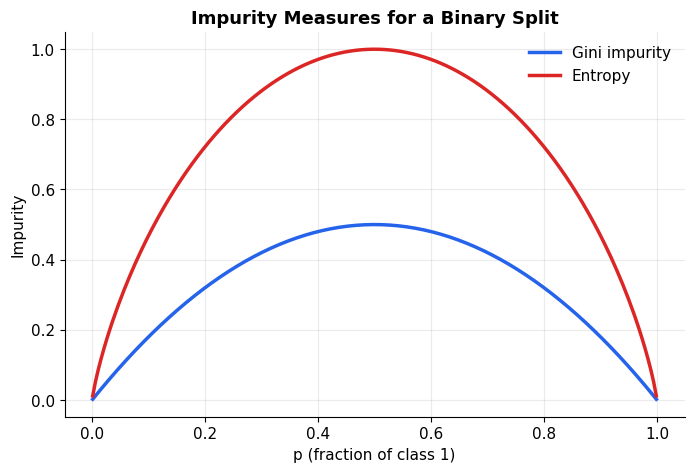

In [13]:
p = np.linspace(0.001, 0.999, 200)
gini = 1 - (p**2 + (1-p)**2)
entropy = -(p*np.log2(p) + (1-p)*np.log2(1-p))

plt.plot(p, gini, color=COLORS[0], lw=2.5, label="Gini impurity")
plt.plot(p, entropy, color=COLORS[1], lw=2.5, label="Entropy")
plt.title("Impurity Measures for a Binary Split")
plt.xlabel("p (fraction of class 1)"); plt.ylabel("Impurity"); plt.legend()
plt.show()

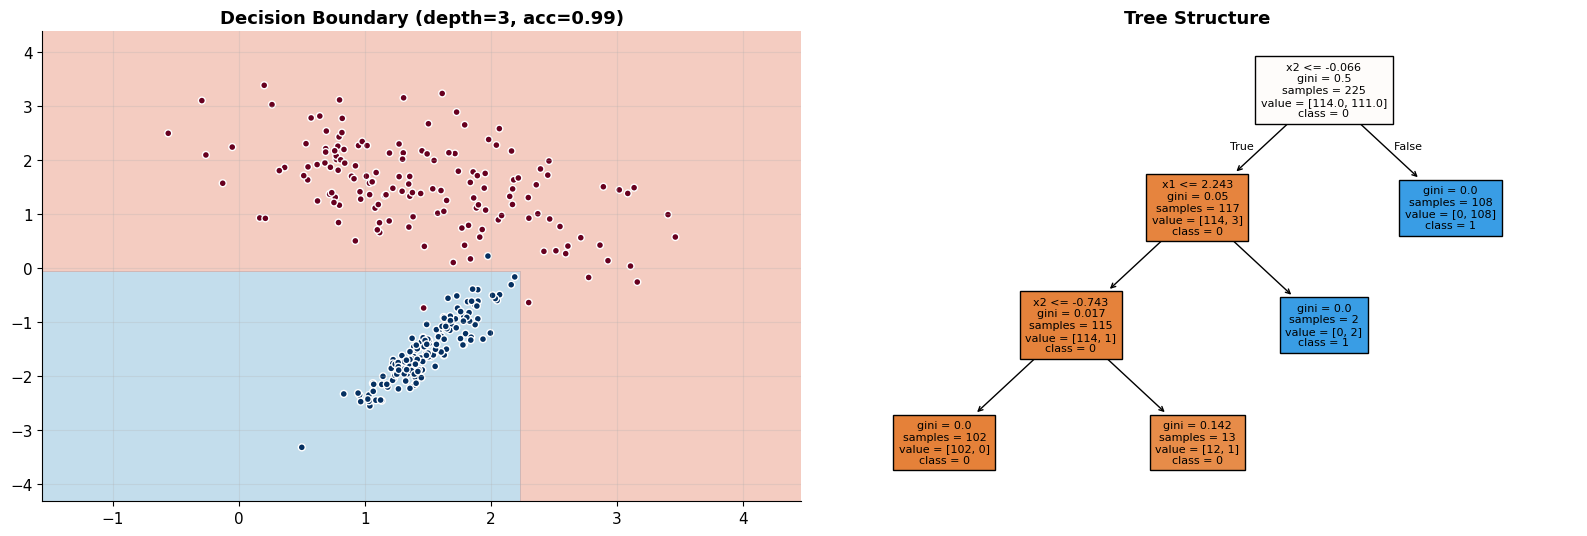

In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
tree = DecisionTreeClassifier(max_depth=3, random_state=42).fit(Xtr, ytr)
Z = tree.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
axes[0].contourf(xx, yy, Z, levels=1, cmap='RdBu_r', alpha=0.4)
axes[0].scatter(Xc[:,0], Xc[:,1], c=yc, cmap='RdBu_r', edgecolor='white', s=25)
axes[0].set_title(f"Decision Boundary (depth=3, acc={accuracy_score(yte, tree.predict(Xte)):.2f})")

plot_tree(tree, filled=True, feature_names=['x1','x2'], class_names=['0','1'], ax=axes[1], fontsize=8)
axes[1].set_title("Tree Structure")
plt.tight_layout(); plt.show()

## 8. Ensembles — Random Forests & Gradient Boosting

### 8.1 Random Forest (Bagging)
Train $B$ trees on bootstrap-resampled data, each considering a random subset of features at every split, then average/vote:
$$\hat{f}(x) = \frac{1}{B}\sum_{b=1}^B \hat{f}_b(x)$$
Reduces **variance** because averaging decorrelated trees cancels out individual noise.

### 8.2 Gradient Boosting
Trees are added **sequentially**, each one fit to the *residual errors* of the ensemble so far:
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x), \qquad h_m \approx \arg\min_h \sum_i \left[-\frac{\partial \ell(y_i, F_{m-1}(x_i))}{\partial F_{m-1}(x_i)} - h(x_i)\right]^2$$
$\eta$ (learning rate) shrinks each tree's contribution, trading speed for generalization. Reduces **bias**.

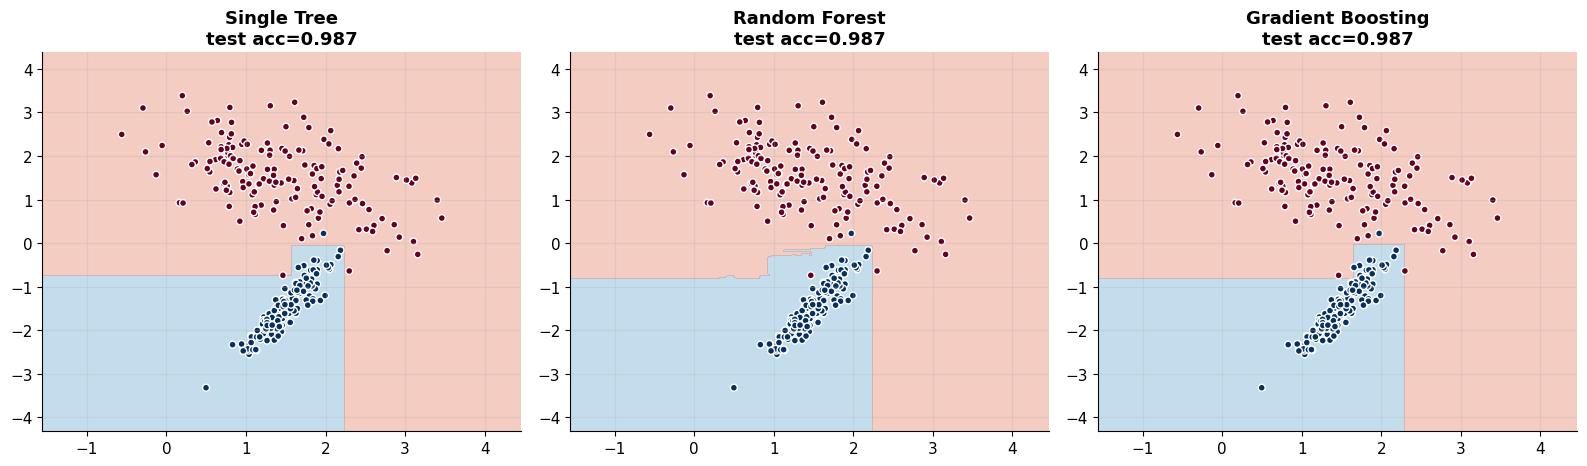

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    "Single Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(Xtr, ytr)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=1, cmap='RdBu_r', alpha=0.4)
    ax.scatter(Xc[:,0], Xc[:,1], c=yc, cmap='RdBu_r', edgecolor='white', s=25)
    acc = accuracy_score(yte, model.predict(Xte))
    ax.set_title(f"{name}\ntest acc={acc:.3f}")
plt.tight_layout(); plt.show()

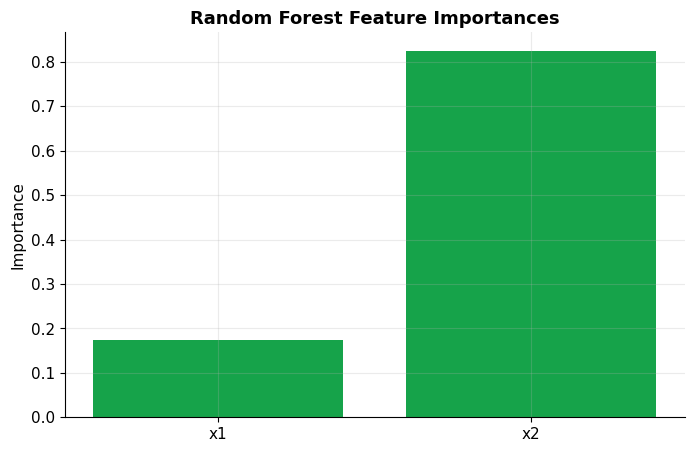

In [16]:
# Feature importance from Random Forest
rf = models["Random Forest"]
plt.bar(['x1','x2'], rf.feature_importances_, color=COLORS[2])
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance")
plt.show()

## 9. Support Vector Machines (SVM)

SVM finds the hyperplane $\theta^\top x + b = 0$ that **maximizes the margin** between classes.

**Hard margin objective:**
$$\min_{\theta,b} \tfrac{1}{2}\|\theta\|^2 \quad \text{s.t. } y^{(i)}(\theta^\top x^{(i)}+b) \geq 1 \; \forall i$$

**Soft margin (allows some violations)** introduces slack $\xi_i \geq 0$ and a penalty $C$:
$$\min_{\theta,b,\xi} \tfrac{1}{2}\|\theta\|^2 + C\sum_i \xi_i$$

**Kernel trick**: replace dot products $x^\top x'$ with a kernel $K(x,x')$ to implicitly map into higher-dimensional space without ever computing the mapping — e.g. RBF kernel $K(x,x')=\exp(-\gamma\|x-x'\|^2)$ lets SVM draw non-linear boundaries.

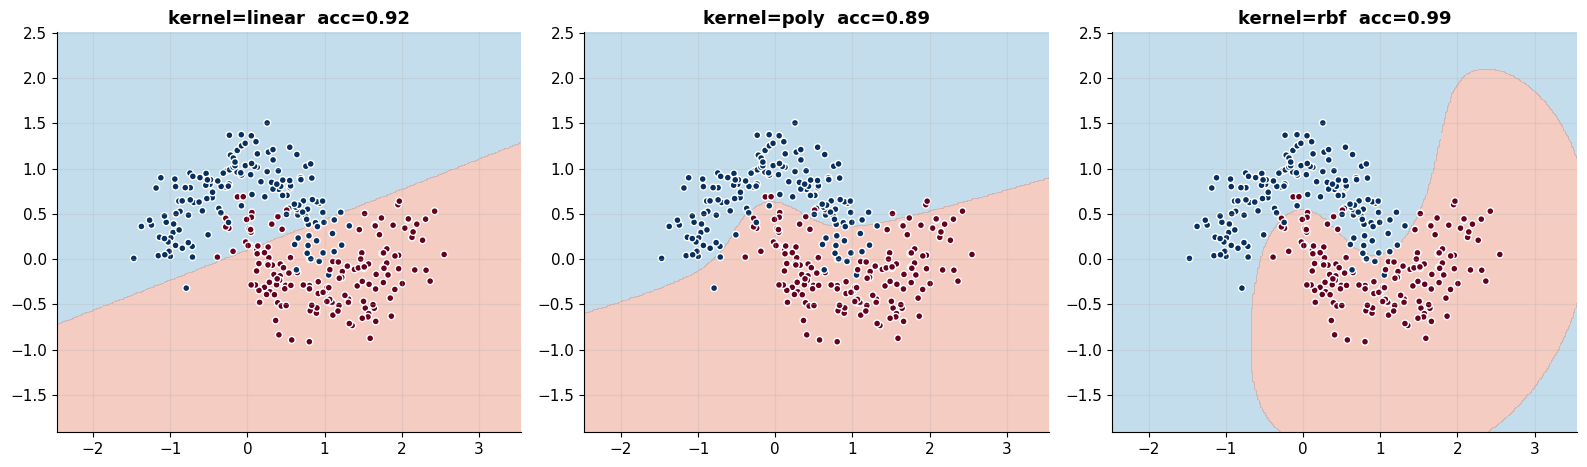

In [17]:
from sklearn.svm import SVC
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=300, noise=0.2, random_state=42)
Xmtr, Xmte, ymtr, ymte = train_test_split(Xm, ym, test_size=0.25, random_state=42)
xx2, yy2 = np.meshgrid(np.linspace(Xm[:,0].min()-1, Xm[:,0].max()+1, 300),
                        np.linspace(Xm[:,1].min()-1, Xm[:,1].max()+1, 300))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, kernel in zip(axes, ['linear', 'poly', 'rbf']):
    svm = SVC(kernel=kernel, C=1.0, gamma='scale').fit(Xmtr, ymtr)
    Z = svm.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z, levels=1, cmap='RdBu_r', alpha=0.4)
    ax.scatter(Xm[:,0], Xm[:,1], c=ym, cmap='RdBu_r', edgecolor='white', s=25)
    acc = accuracy_score(ymte, svm.predict(Xmte))
    ax.set_title(f"kernel={kernel}  acc={acc:.2f}")
plt.tight_layout(); plt.show()

## 10. Neural Networks — From Perceptron to Backpropagation

### 10.1 A single neuron
$$z = w^\top x + b, \qquad a = g(z)$$
where $g$ is a non-linear **activation function** (ReLU, sigmoid, tanh). Without non-linearity, stacking layers is mathematically equivalent to a single linear layer.

### 10.2 Forward pass (2-layer network)
$$z^{[1]} = W^{[1]}x + b^{[1]}, \quad a^{[1]} = g(z^{[1]}), \quad z^{[2]} = W^{[2]}a^{[1]} + b^{[2]}, \quad \hat y = \sigma(z^{[2]})$$

### 10.3 Backpropagation
Backprop is just the **chain rule** applied layer by layer, computing $\partial J/\partial W$ from the output backwards:
$$\delta^{[2]} = \hat y - y, \qquad \delta^{[1]} = (W^{[2]})^\top \delta^{[2]} \odot g'(z^{[1]})$$
$$\frac{\partial J}{\partial W^{[l]}} = \delta^{[l]} (a^{[l-1]})^\top$$
Then every weight updates via gradient descent: $W \leftarrow W - \alpha \, \partial J/\partial W$.

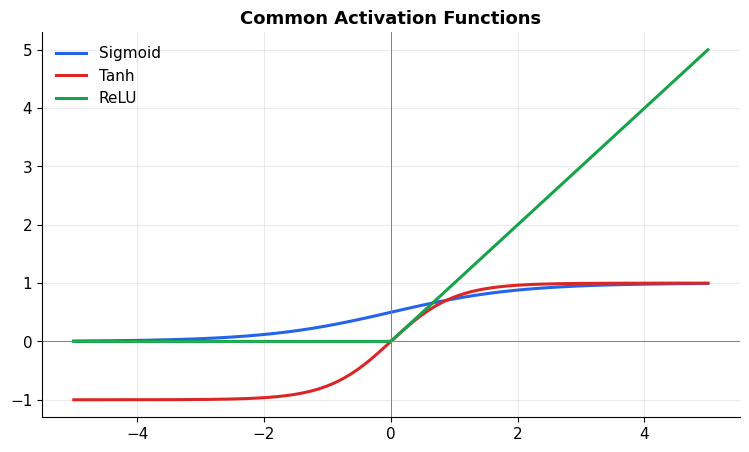

In [18]:
# Activation functions
z = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(z, 1/(1+np.exp(-z)), label="Sigmoid", color=COLORS[0], lw=2.2)
ax.plot(z, np.tanh(z), label="Tanh", color=COLORS[1], lw=2.2)
ax.plot(z, np.maximum(0, z), label="ReLU", color=COLORS[2], lw=2.2)
ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
ax.set_title("Common Activation Functions"); ax.legend()
plt.show()

From-scratch NN test accuracy: 1.000


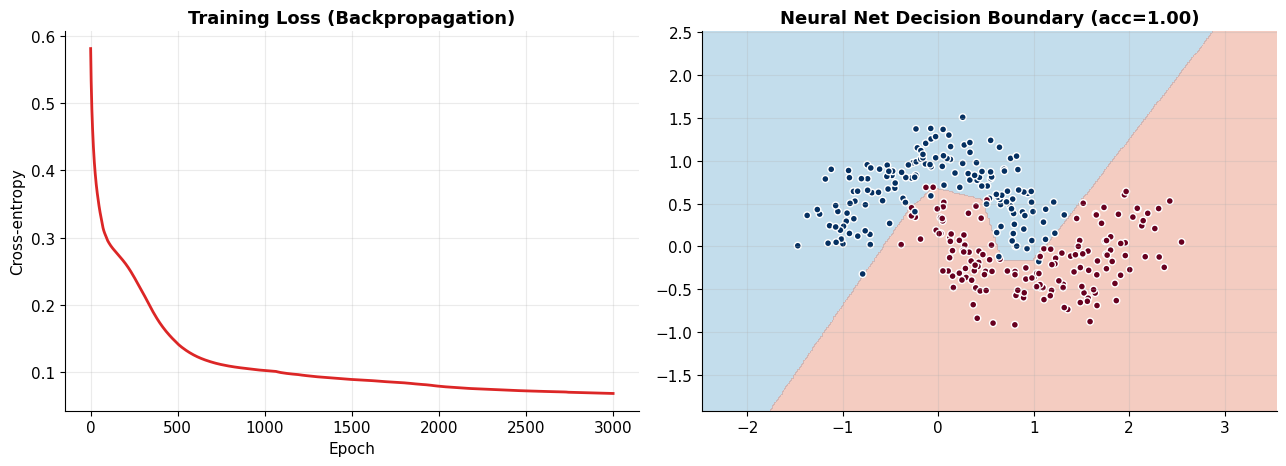

In [19]:
# --- A 2-layer neural net from scratch (numpy only) trained on the moons dataset ---
def relu(z): return np.maximum(0, z)
def relu_deriv(z): return (z > 0).astype(float)
def sigmoid(z): return 1/(1+np.exp(-z))

np.random.seed(1)
n_in, n_hidden, n_out = 2, 8, 1
W1 = np.random.randn(n_hidden, n_in) * 0.5
b1 = np.zeros((n_hidden,1))
W2 = np.random.randn(n_out, n_hidden) * 0.5
b2 = np.zeros((n_out,1))

X_nn = Xmtr.T                  # shape (2, n)
Y_nn = ymtr.reshape(1,-1)      # shape (1, n)
lr, epochs = 0.5, 3000
losses = []

for epoch in range(epochs):
    # forward
    Z1 = W1 @ X_nn + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    m = X_nn.shape[1]
    loss = -np.mean(Y_nn*np.log(A2+1e-9) + (1-Y_nn)*np.log(1-A2+1e-9))
    losses.append(loss)

    # backward (chain rule)
    dZ2 = A2 - Y_nn
    dW2 = dZ2 @ A1.T / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = dZ1 @ X_nn.T / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    W1 -= lr*dW1; b1 -= lr*db1; W2 -= lr*dW2; b2 -= lr*db2

def nn_predict(X):
    A1 = relu(W1 @ X.T + b1)
    A2 = sigmoid(W2 @ A1 + b2)
    return (A2 > 0.5).astype(int).ravel()

acc = np.mean(nn_predict(Xmte) == ymte)
print(f"From-scratch NN test accuracy: {acc:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(losses, color=COLORS[1], lw=2)
axes[0].set_title("Training Loss (Backpropagation)"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy")

Zg = nn_predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
axes[1].contourf(xx2, yy2, Zg, levels=1, cmap='RdBu_r', alpha=0.4)
axes[1].scatter(Xm[:,0], Xm[:,1], c=ym, cmap='RdBu_r', edgecolor='white', s=25)
axes[1].set_title(f"Neural Net Decision Boundary (acc={acc:.2f})")
plt.tight_layout(); plt.show()

In [20]:
# sklearn MLPClassifier for comparison
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(16,8), max_iter=2000, random_state=42).fit(Xmtr, ymtr)
print(f"sklearn MLP test accuracy: {accuracy_score(ymte, mlp.predict(Xmte)):.3f}")

sklearn MLP test accuracy: 0.973


## 11. Learning Curves & Cross-Validation

A **learning curve** plots training vs. validation error as training-set size grows:
- Both errors high & converged → **high bias** (underfitting) → get a more powerful model.
- Large gap between them → **high variance** (overfitting) → get more data / regularize.

**k-fold cross-validation** splits data into $k$ folds, trains on $k-1$, validates on the last, and rotates — giving a more robust estimate of generalization error than a single train/test split.

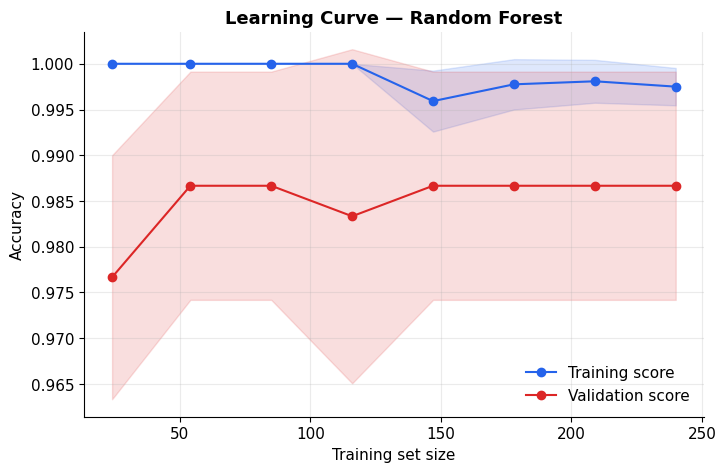

5-fold CV accuracy: 0.987 +/- 0.012


In [21]:
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42),
    Xc, yc, cv=5, train_sizes=np.linspace(0.1, 1.0, 8), scoring='accuracy')

plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color=COLORS[0], label='Training score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color=COLORS[1], label='Validation score')
plt.fill_between(train_sizes, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.15, color=COLORS[0])
plt.fill_between(train_sizes, val_scores.mean(1)-val_scores.std(1), val_scores.mean(1)+val_scores.std(1), alpha=0.15, color=COLORS[1])
plt.title("Learning Curve — Random Forest"); plt.xlabel("Training set size"); plt.ylabel("Accuracy"); plt.legend()
plt.show()

scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42), Xc, yc, cv=5)
print(f"5-fold CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")

## 12. Summary Cheat-Sheet

| Algorithm | Type | Key idea | Watch out for |
|---|---|---|---|
| Linear Regression | Regression | Fit a hyperplane, minimize MSE | Assumes linearity |
| Logistic Regression | Classification | Sigmoid + cross-entropy | Linear decision boundary |
| Ridge / Lasso | Regularization | Penalize large weights | Choosing $\lambda$ |
| KNN | Both | Vote among nearest neighbors | Slow at prediction, curse of dimensionality |
| Decision Tree | Both | Recursive splits by impurity | Overfits if unpruned |
| Random Forest | Both | Bagging of trees | Less interpretable |
| Gradient Boosting | Both | Sequential residual fitting | Sensitive to overfitting, tuning-heavy |
| SVM | Classification | Max-margin hyperplane + kernels | Doesn't scale well to huge datasets |
| Neural Network | Both | Layers of weighted sums + non-linearities | Needs lots of data, many hyperparameters |

**General workflow:** split data → explore & preprocess → pick a baseline model → evaluate with cross-validation → tune hyperparameters → check learning curves for bias/variance → regularize as needed → finalize.